## Load Clean Dataset

In [1]:
import pandas as pd

pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [2]:
df = pd.read_csv('../data/CleanData.csv') # This is the clean dataset, which we built in "data_cleaning.ipynb"

In [3]:
df.head()

,date,amount,use_chip,merchant_city,errors,current_age,retirement_age,gender,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,card_brand,card_type,expires,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,merchant_category,target,trans_count_cli,avg_amount_cli,max_amount_cli,trans_count_card
0,2010-01-01 00:02:00,14.57,Swipe Transaction,Bettendorf,No errors,48,67,Male,40.80,-91.12,18076.0,36853.0,112139.0,834,5,Mastercard,Credit,2024-12-01,YES,1,9100.0,2005-09-01,2015,Department Stores,0,7446,33.474038,1139.95,2481
1,2010-01-01 00:02:00,80.00,Swipe Transaction,Vista,No errors,49,65,Male,33.18,-117.29,16894.0,34449.0,36540.0,686,3,Mastercard,Debit,2020-05-01,YES,1,14802.0,2006-01-01,2008,Money Transfer,0,9314,55.776330,1129.61,4283
2,2010-01-01 00:06:00,46.41,Swipe Transaction,Harwood,No errors,51,69,Male,38.86,-76.60,33529.0,68362.0,96182.0,711,2,Visa,Debit,2020-01-01,YES,1,19113.0,2009-07-01,2014,Drinking Places (Alcoholic Beverages),0,4190,80.990702,1244.73,2310
3,2010-01-01 00:07:00,4.81,Swipe Transaction,Bronx,No errors,47,65,Female,40.84,-73.87,25537.0,52065.0,98613.0,828,5,Mastercard,Debit (Prepaid),2014-03-01,YES,1,89.0,2008-01-01,2015,Book Stores,0,12885,51.449454,1744.05,3165
4,2010-01-01 00:14:00,26.46,Online Transaction,ONLINE,No errors,56,65,Male,36.34,-83.28,13668.0,27861.0,108313.0,782,5,Mastercard,Debit (Prepaid),2021-05-01,YES,1,46.0,2007-03-01,2012,Tolls and Bridge Fees,0,9051,32.939269,834.96,2095


## Feature Engineering

These transformations will be applied to both training and production data:

1) **Temporal features from date:**
    - Time of transaction
    - Day of week
    - Month and day
    - Years since account opening
    - Years since last PIN change
    - Days until card expiration

2) **Retirement status from age fields:**
    - Compute `years_retired` = max(0, current_age - retirement_age)

In [4]:
# Temporal features

df['date'] = pd.to_datetime(df['date'])

df['hour'] = df['date'].dt.hour # The dt accessor lets us apply vectorized operations (faster)

df['day_of_week'] = df['date'].dt.dayofweek # 0 -> Monday, 6 -> Sunday

df['month'] = df['date'].dt.month

df['day'] = df['date'].dt.day

In [5]:
# Date differences

df['acct_open_date'] = pd.to_datetime(df['acct_open_date'])
df['expires'] = pd.to_datetime(df['expires'])

df['days_since_acct_open'] = (df['date'] - df['acct_open_date']).dt.days
df['days_until_expiration'] = (df['expires'] - df['date']).dt.days

We verify if there are any negative values:
- Cannot have transactions before account is open
- Transactions with expired cards should have an error



In [6]:
df[df['days_since_acct_open'] < 0]

,date,amount,use_chip,merchant_city,errors,current_age,retirement_age,gender,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,card_brand,card_type,expires,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,merchant_category,target,trans_count_cli,avg_amount_cli,max_amount_cli,trans_count_card,hour,day_of_week,month,day,days_since_acct_open,days_until_expiration
493,2010-01-01 09:02:00,143.69,Swipe Transaction,Dallas,No errors,83,59,Male,40.95,-72.19,37846.0,80493.0,2027.0,610,5,Mastercard,Credit,2024-07-01,YES,1,17400.0,2010-02-01,2010,Ironwork,0,8255,54.884935,1842.48,3112,9,4,1,1,-31,5294
2143,2010-01-01 22:44:00,692.30,Swipe Transaction,Goshen,No errors,44,66,Female,39.39,-84.56,19569.0,39898.0,43630.0,682,3,Mastercard,Credit,2021-08-01,YES,2,14100.0,2010-02-01,2010,Miscellaneous Metals,0,9786,45.847438,933.54,7531,22,4,1,1,-31,4229
2692,2010-01-02 09:32:00,1411.14,Swipe Transaction,Fort Worth,No errors,46,67,Male,32.83,-97.17,30913.0,63030.0,93406.0,791,5,Mastercard,Credit,2023-04-01,YES,2,9700.0,2010-02-01,2011,Leather Goods,0,10156,46.060128,1628.89,1867,9,5,1,2,-30,4836
6876,2010-01-04 09:53:00,703.85,Swipe Transaction,Meredosia,No errors,47,66,Female,39.85,-88.93,22153.0,45164.0,0.0,730,3,Mastercard,Debit,2015-11-01,YES,1,16373.0,2010-02-01,2010,Miscellaneous Metals,0,3436,49.907369,1025.72,1034,9,0,1,4,-28,2126
8355,2010-01-05 03:25:00,1812.76,Swipe Transaction,Liberty,No errors,43,70,Female,34.83,-82.37,24314.0,49577.0,142314.0,694,3,Visa,Debit,2021-10-01,YES,2,21022.0,2010-02-01,2011,"Brick, Stone, and Related Materials",0,9318,79.430835,1973.74,5979,3,1,1,5,-27,4286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7219410,2018-06-03 22:25:00,1213.91,Chip Transaction,Sacramento,No errors,26,66,Female,38.10,-122.63,30335.0,61850.0,81158.0,728,9,Visa,Debit,2022-07-01,YES,2,34888.0,2019-04-01,2019,"Tools, Parts, Supplies Manufacturing",0,5478,43.054757,1964.84,102,22,6,6,3,-302,1488
7681674,2018-12-11 00:15:00,527.42,Online Transaction,ONLINE,No errors,53,67,Male,41.80,-87.92,92938.0,189490.0,448929.0,717,3,Visa,Debit,2024-02-01,YES,2,64613.0,2019-01-01,2019,Airlines,0,460,183.828652,1721.94,245,0,1,12,11,-21,1877
7868902,2019-02-25 19:35:00,704.03,Chip Transaction,Remsen,No errors,27,74,Female,41.72,-93.60,29680.0,60510.0,23196.0,790,3,Visa,Debit,2022-08-01,YES,2,22330.0,2019-06-01,2019,"Tools, Parts, Supplies Manufacturing",0,7770,53.166852,1040.91,139,19,0,2,25,-96,1252
7926553,2019-03-21 15:22:00,274.44,Chip Transaction,Limestone,No errors,38,65,Male,35.06,-85.25,21988.0,44831.0,20906.0,705,3,Mastercard,Debit,2021-01-01,YES,2,31741.0,2019-08-01,2019,Steelworks,0,7316,41.951657,535.52,137,15,3,3,21,-133,651


In [7]:
df[(df['days_until_expiration'] <= 0) & (df['errors']=='No errors')]

,date,amount,use_chip,merchant_city,errors,current_age,retirement_age,gender,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,card_brand,card_type,expires,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,merchant_category,target,trans_count_cli,avg_amount_cli,max_amount_cli,trans_count_card,hour,day_of_week,month,day,days_since_acct_open,days_until_expiration
4552,2010-01-03 08:28:00,7.97,Swipe Transaction,Houston,No errors,57,66,Female,29.76,-95.38,14959.0,30495.0,70825.0,773,4,Discover,Credit,2010-01-01,YES,1,8100.0,2006-08-01,2008,"Package Stores, Beer, Wine, Liquor",0,13424,35.374289,970.23,19,8,6,1,3,1251,-3
6117,2010-01-03 22:16:00,59.77,Swipe Transaction,Lake Hopatcong,No errors,42,72,Male,40.96,-74.61,34205.0,69747.0,80763.0,741,4,Visa,Credit,2010-01-01,YES,1,15900.0,2009-02-01,2009,Beauty and Barber Shops,0,9279,44.189254,932.01,17,22,6,1,3,336,-3
7317,2010-01-04 12:46:00,38.37,Swipe Transaction,Lake Hopatcong,No errors,42,72,Male,40.96,-74.61,34205.0,69747.0,80763.0,741,4,Visa,Credit,2010-01-01,YES,1,15900.0,2009-02-01,2009,Drinking Places (Alcoholic Beverages),0,9279,44.189254,932.01,17,12,0,1,4,337,-4
8515,2010-01-05 06:53:00,23.86,Swipe Transaction,Houston,No errors,57,66,Female,29.76,-95.38,14959.0,30495.0,70825.0,773,4,Discover,Credit,2010-01-01,YES,1,8100.0,2006-08-01,2008,Automotive Service Shops,0,13424,35.374289,970.23,19,6,1,1,5,1253,-5
10815,2010-01-06 07:58:00,1.93,Swipe Transaction,Houston,No errors,57,66,Female,29.76,-95.38,14959.0,30495.0,70825.0,773,4,Discover,Credit,2010-01-01,YES,1,8100.0,2006-08-01,2008,"Grocery Stores, Supermarkets",0,13424,35.374289,970.23,19,7,2,1,6,1254,-6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8471545,2019-10-31 15:59:00,160.00,Chip Transaction,San Mateo,No errors,68,64,Female,37.74,-122.44,51692.0,88432.0,63075.0,694,6,Visa,Credit,2019-11-01,YES,2,17100.0,2018-06-01,2018,Money Transfer,0,9604,140.590702,2505.91,856,15,3,10,31,517,0
8471572,2019-10-31 16:11:00,86.13,Chip Transaction,Miami,No errors,59,67,Male,25.77,-80.20,53676.0,109440.0,180865.0,737,5,Visa,Credit,2019-10-01,YES,2,37400.0,2011-12-01,2011,Automotive Service Shops,0,11084,82.830699,1761.58,4338,16,3,10,31,2891,-31
8471639,2019-10-31 16:36:00,152.86,Chip Transaction,Fremont,No errors,68,64,Female,37.74,-122.44,51692.0,88432.0,63075.0,694,6,Visa,Credit,2019-11-01,YES,2,17100.0,2018-06-01,2018,Miscellaneous Home Furnishing Stores,0,9604,140.590702,2505.91,856,16,3,10,31,517,0
8472005,2019-10-31 20:43:00,7.00,Online Transaction,ONLINE,No errors,49,70,Male,35.06,-85.25,18658.0,38041.0,27813.0,782,4,Visa,Debit,2019-11-01,YES,2,17245.0,2019-06-01,2019,Tolls and Bridge Fees,0,9488,38.609960,1054.75,94,20,3,10,31,152,0


There aren't a lot of cases, so we may drop them. These are probably due to errors during the data generation. We will add all these verifications in our production pipeline.

In [8]:
condition_expiration = (df['days_until_expiration'] <= 0) & (df['errors']=='No errors')
condition_acct_open = (df['days_since_acct_open'] < 0)

df = df[~(condition_expiration | condition_acct_open)]

print(f'Number of entries: {len(df)}.')



Number of entries: 8457337.


In [9]:
df['years_since_pin_change'] = (df['date'].dt.year - df['year_pin_last_changed']).astype(int)

In [10]:
df['years_since_pin_change'] = df['years_since_pin_change'].apply(lambda x: x if x> 0 else 0)

In [11]:
# We can now drop the date features

df.drop(['date', 'expires', 'acct_open_date'], axis=1, inplace=True)

In [12]:
df.drop('year_pin_last_changed', axis=1, inplace=True)

In [13]:
df['years_retired'] = df['current_age'] - df['retirement_age']

In [14]:
df['years_retired'] = df['years_retired'].apply(lambda x: max(0,x))

In [15]:
df.drop('retirement_age', axis=1, inplace=True)

## Data Encoding

Since our modeling approach uses tree-based algorithms that natively handle categorical variables, explicit feature encoding is unnecessary.

## Data Splitting

**Note:** As acknowledged earlier, a time-based train-test split would be more appropriate for this temporal dataset to prevent leakage and properly evaluate generalization. However, for this project a standard random split is used for simplicity.

In [16]:
print(f"Non-fraudulent operations: {len(df[df['target']==0])}.")
print(f"Fraudulent operations: {len(df[df['target']==1])}.")

Non-fraudulent operations: 8444529.
Fraudulent operations: 12808.


Given the **severe** class imbalance in the dataset, a **stratified train-test split** is used to maintain the fraud proportion in both training and test sets.

In [17]:
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, # Standard 80-20
    stratify=y, # Same fraud ratio in both sets
    random_state=123
)

In [18]:
print(f'Train features shape: {X_train.shape}')
print(f'Test features shape: {X_test.shape}')
print(f'Train fraud rate: {y_train.mean():.5f}')
print(f'Test fraud rate: {y_test.mean():.5f}')

Train features shape: (6765869, 31)
Test features shape: (1691468, 31)
Train fraud rate: 0.00151
Test fraud rate: 0.00151


## Evaluation Metrics

Selecting appropriate evaluation metrics is critical in fraud detection, where class imbalance
is severe and the cost of errors is asymmetric.

The two core metrics in this setting are:

- **Recall:** The fraction of actual fraud cases the model correctly identifies. Low recall
  means missed fraud —> direct financial loss.
- **Precision:** The fraction of fraud predictions that are actually fraud. Low precision
  means false alarms —> customer friction and operational costs.

These two metrics are in tension: lowering the classification threshold increases recall but
reduces precision, and vice versa.

*Note: The **classification threshold** is the probability cutoff
above which a transaction is labeled as fraud. Since 0.5 is rarely optimal under class
imbalance, the threshold is treated as a tunable parameter rather than a fixed default.*

In this setting, the primary evaluation metric is **PR-AUC (Precision-Recall Area Under the Curve)**, which
summarizes model performance across all possible thresholds — making it more informative than
ROC-AUC in imbalanced settings, where an abundance of true negatives can inflate ROC scores
without reflecting real fraud-catching ability.

## Model Selection

In [19]:
cat_columns = ['use_chip', 'merchant_city', 'errors', 'gender', 'card_brand', 'card_type', 'has_chip', 'merchant_category']

for col in cat_columns:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    enable_categorical=True,
    tree_method='hist', # Uses histogram-based algorithms for building trees (continuous data is split into buckets and those bucket boundaries are used to split trees)
    eval_metric='aucpr'
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [ ]:
y_pred_xgb = xgb_model.predict_proba(X_test)[:,1]

In [ ]:
y_pred_xgb

array([2.4785554e-06, 2.3470591e-06, 4.8635038e-06, ..., 1.3925605e-04,
       1.3353295e-09, 9.9013363e-05], shape=(1691468,), dtype=float32)

In [ ]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    metric="average_precision"
)

lgbm_model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [ ]:
y_pred_lgbm = lgbm_model.predict_proba(X_test)[:,1]

In [ ]:
y_pred_lgbm

array([0.00000000e+000, 8.39370191e-008, 3.34126480e-008, ...,
       9.55982344e-139, 7.18393287e-008, 3.25062620e-010],
      shape=(1691468,))

In [ ]:
from catboost import CatBoostClassifier

catboost_model = CatBoostClassifier(
    eval_metric='PRAUC',
    iterations=100, # If we don't add this it takes too long
    early_stopping_rounds=10
)

catboost_model.fit(X_train, y_train, cat_features = cat_columns)

Learning rate set to 0.5
0:	learn: 0.0107723	total: 7.1s	remaining: 11m 43s
1:	learn: 0.0908054	total: 12.4s	remaining: 10m 5s
2:	learn: 0.3038606	total: 16.7s	remaining: 8m 58s
3:	learn: 0.3505943	total: 21.2s	remaining: 8m 29s
4:	learn: 0.3514142	total: 25.9s	remaining: 8m 11s
5:	learn: 0.3844282	total: 30.8s	remaining: 8m 2s
6:	learn: 0.3870685	total: 36.3s	remaining: 8m 2s
7:	learn: 0.5131108	total: 42.2s	remaining: 8m 4s
8:	learn: 0.5208841	total: 47.9s	remaining: 8m 4s
9:	learn: 0.5385182	total: 54.9s	remaining: 8m 14s
10:	learn: 0.5438032	total: 1m	remaining: 8m 13s
11:	learn: 0.5514557	total: 1m 6s	remaining: 8m 7s
12:	learn: 0.5533410	total: 1m 12s	remaining: 8m 5s
13:	learn: 0.5553472	total: 1m 18s	remaining: 8m 5s
14:	learn: 0.5559514	total: 1m 24s	remaining: 8m
15:	learn: 0.5623188	total: 1m 30s	remaining: 7m 54s
16:	learn: 0.5696602	total: 1m 35s	remaining: 7m 48s
17:	learn: 0.5774889	total: 1m 42s	remaining: 7m 45s
18:	learn: 0.5793342	total: 1m 49s	remaining: 7m 46s
19:	

CatBoostClassifier(early_stopping_rounds=10, eval_metric='PRAUC', iterations=100)

In [ ]:
y_pred_catboost = catboost_model.predict_proba(X_test)[:,1]

In [ ]:
y_pred_catboost

array([2.70794156e-05, 5.37295543e-06, 1.39679319e-05, ...,
       2.41239732e-05, 7.37773223e-05, 4.64620780e-05], shape=(1691468,))

In [ ]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

C:\Users\pablo\AppData\Local\Temp\ipykernel_45740\4053731127.py:35: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


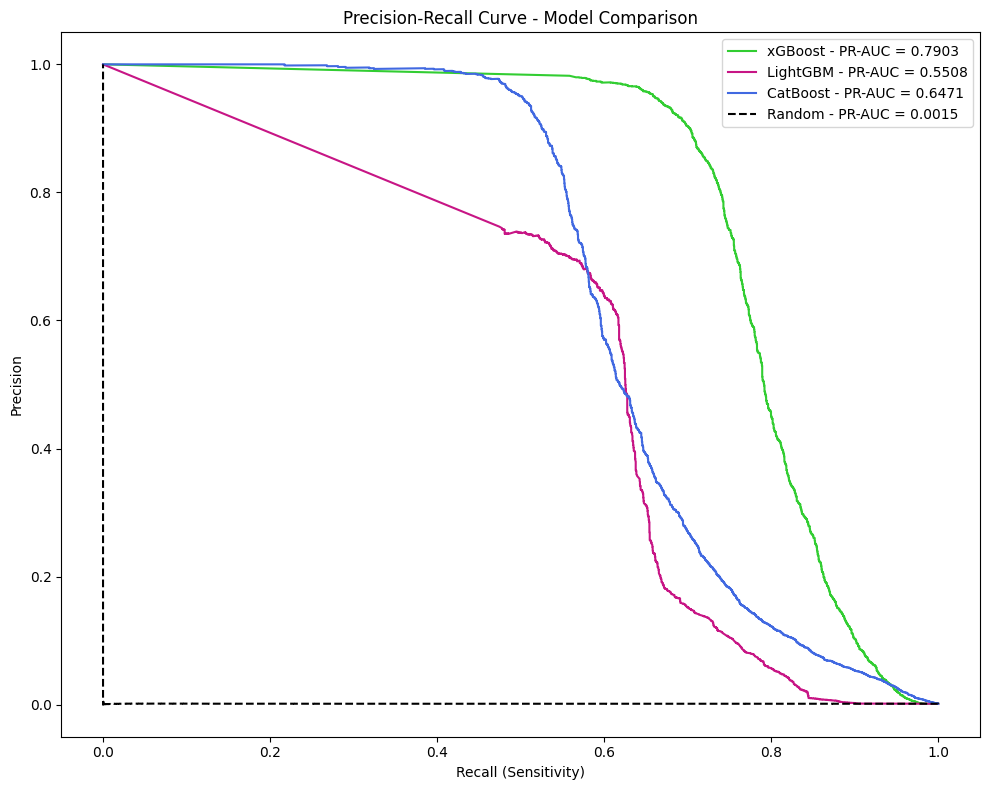

In [ ]:
import numpy as np

y_pred_random = np.random.uniform(0,1, size=len(y_test)) # Random model as baseline, predicts probabilities at random

preds = {
    'xGBoost': y_pred_xgb,
    'LightGBM': y_pred_lgbm,
    'CatBoost': y_pred_catboost,
    'Random': y_pred_random
}

model_colors = {
    'xGBoost': 'limegreen',
    'LightGBM': 'mediumvioletred',
    'CatBoost': 'royalblue',
    'Random': 'black'
}


plt.figure(figsize=(10,8))

for model_name, y_pred in preds.items():
    precision, recall, _ = precision_recall_curve(y_test, y_pred)
    pr_auc = auc(recall, precision)
    plt.plot(recall,
             precision,
             label=f'{model_name} - PR-AUC = {pr_auc:.4f}',
             color=model_colors[model_name],
             linestyle='--' if model_name=='Random' else None)

plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Model Comparison")
plt.legend()
plt.tight_layout()
plt.show()



XGBoost achieves the highest PR-AUC of **0.79** and is selected as the primary model for
the remaining phases.

## Feature Importance

### SHAP Values

**SHAP** (SHapley Additive exPlanations) is a framework for explaining the outputs of any ML model. It helps us figure out 'how much did each feature contribute to a specific prediction?'.

The math comes from cooperative game theory - each feature is treated as a "player" in a game, and SHAP computes the fair contribution of each player to the final outcome (i.e. the prediction).

#### How to interpret SHAP values?

For every prediction, each feature gets assigned a SHAP value:
- **Positive SHAP value** indicates that the feature pushed the prediction towards the positive class (i.e. fraud).
- **Negative SHAP value** indicates that the feature pushed the prediction away from the positive class (i.e. not fraud).
- **Magnitude** indicates how strongly it pushed in that direction.

The SHAP values for a single prediction are additive, meaning:

$$
\text{final prediction} = \text{base value} + \sum_{i \in \text{features}} {SHAP}_i
$$
where base value is the model's average prediction across the training set - the starting point before any feature information is used.

#### How to use SHAP values?

SHAP values can helps us analyze feature importance in three levels:

1. **Global importance: which features matter most overall** -> $\text{Global SHAP}_i = \frac{1}{N}\sum_{j=1}^N |{SHAP}_i^{(j)}|$ for all $i \in \text{features}$.
2. **Global behavior: how does each feature influence predictions directionally** - visualizations of all SHAP values of a feature across all training samples simultaneously.
3. **Local explanation: why did the model predict this for a specific sample**


c:\Users\pablo\Projects\FraudDetection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


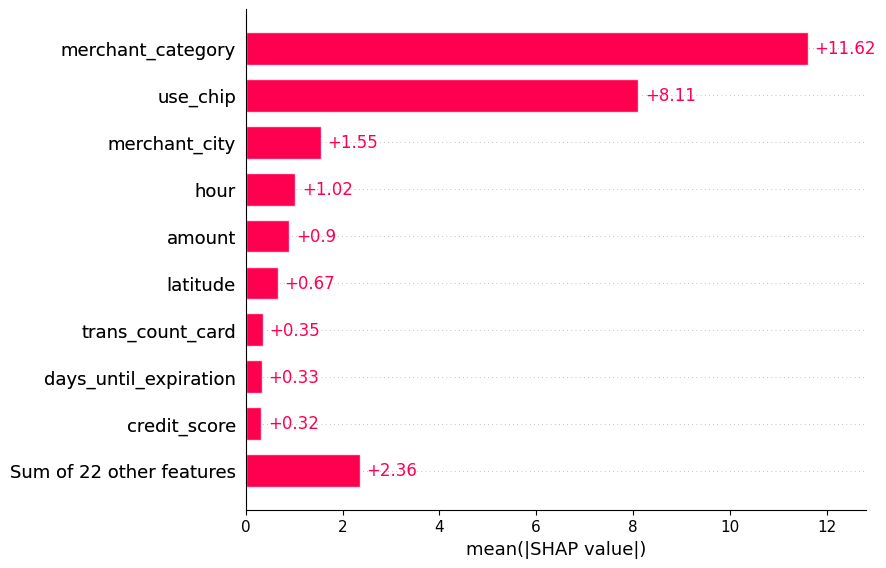

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer(X_test)

shap.plots.bar(shap_values) # Global importance

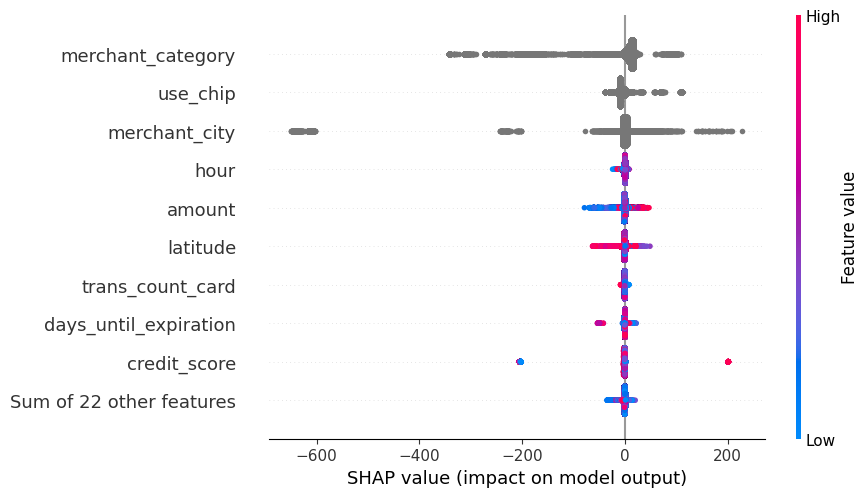

In [ ]:
shap.plots.beeswarm(shap_values) # Global behavior

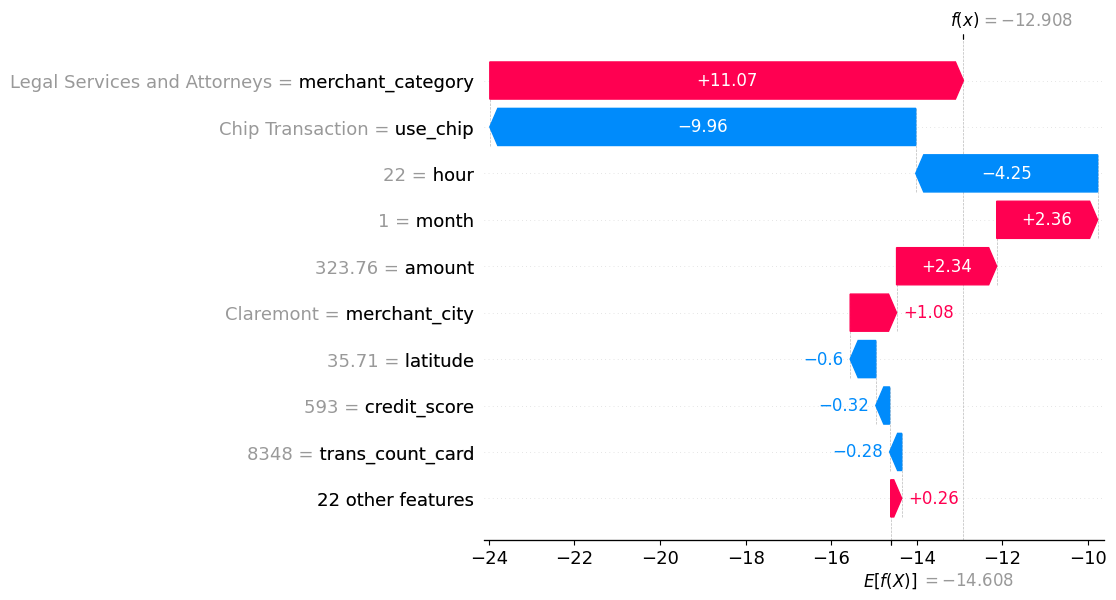

In [ ]:
shap.plots.waterfall(shap_values[0]) # Local explanation for first prediction

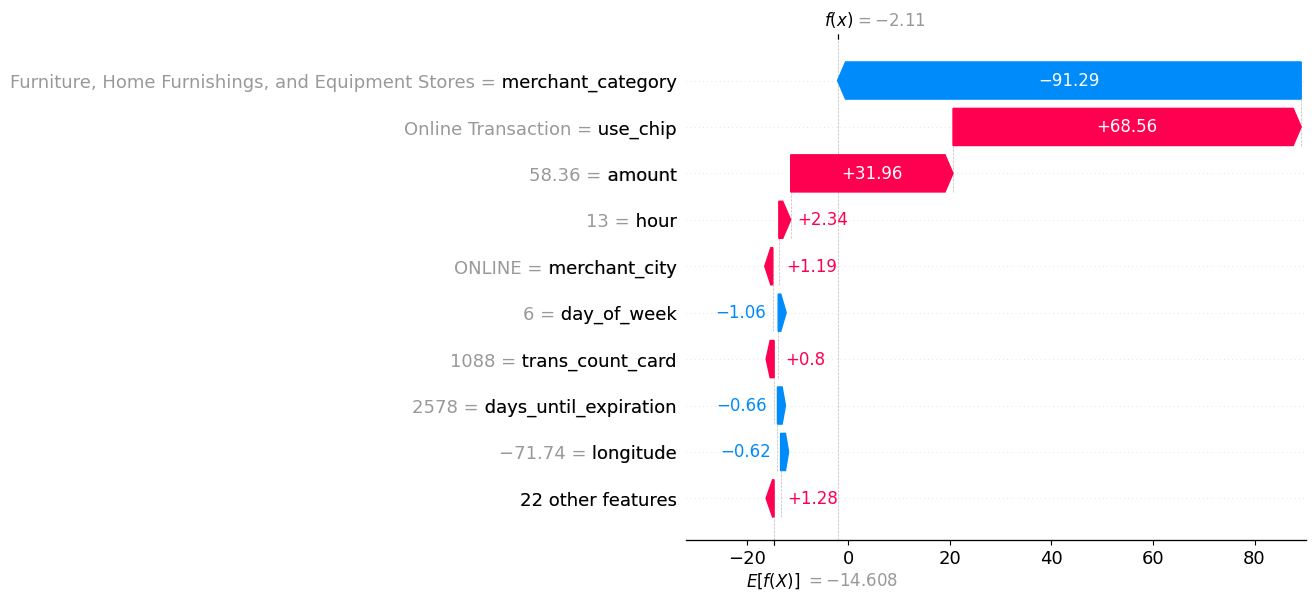

In [ ]:
first_fraud_idx = np.where(y_test==1)[0][0]

shap.plots.waterfall(shap_values[first_fraud_idx]) # Waterfall plot for a fraud transaction

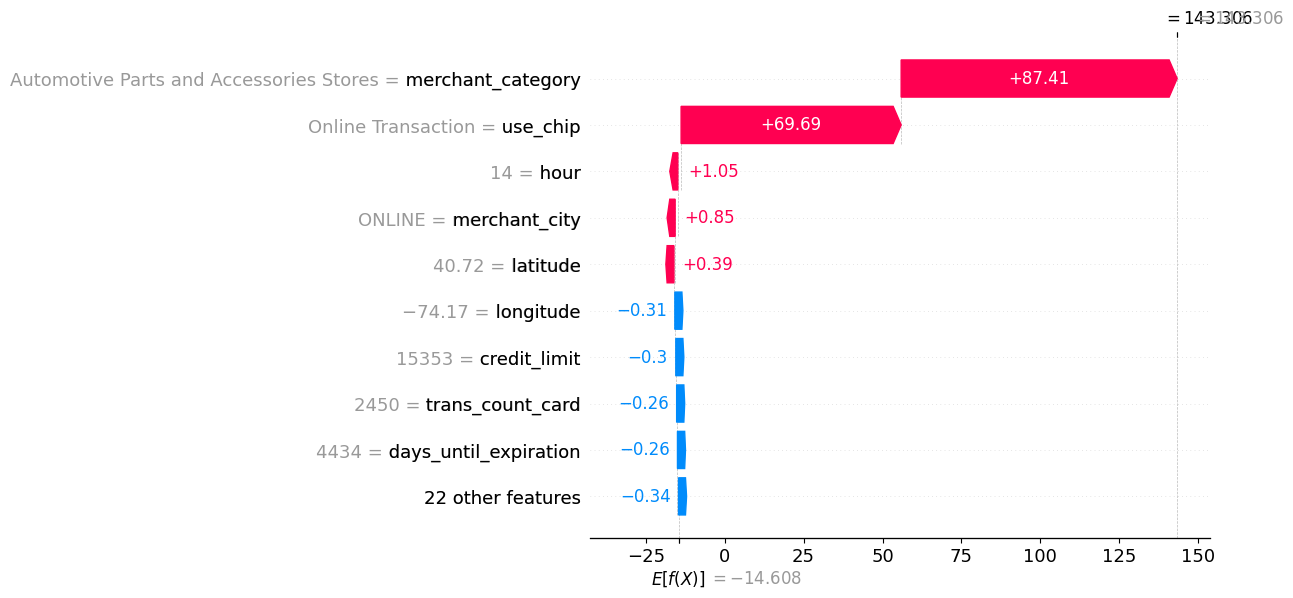

In [ ]:
second_fraud_idx = np.where(y_test==1)[0][1]

shap.plots.waterfall(shap_values[second_fraud_idx]) # Waterfall plot for a fraud transaction

### Model Interpretability - Key findings

1. `merchant_category` and `use_chip` are the **dominant** fraud predictors. All other features contribute marginally by comparison. These two predictors likely interact strongly, i.e. the model has learned that, for example, online transactions in specific merchant categories are often fraudulent.

2. **Online transactions** are consistently assigned significant positive SHAP values. This makes intuitive sense, because in today's digital world it is easier to execute fraud without a physical card rather than in-person fraud (many methods such as *phising*, *credential theft*, etc.).

3. Certain **merchant categories** act as strong fraud signals: for instance, "Automotive Parts and Accessories Stores". This is likely because they support high online transaction volume with low purchase verification. Conversely, categories like "Home Furniture" are safer against fraud, possibly because high-price physical goods involve more friction, verification, etc. 

4. **Higher amounts** produce larger positive SHAP values, which is consistent with the intuition that fraudsters target higher-value transactions to maximize return per operation (low amounts are not worth the risk, basically).

5. Transactions associated with clients living in **higher latitudes** tend to receive slightly negative SHAP values. This may be caused by an underrepresentation of northern regions in the dataset, so this finding should be treated with caution.





## Model Tuning

Due to limited local computational resources, the hyperparameter search is subject to the following constraints:
  - Training data is subsampled to 50% for tuning only (full dataset is used for final model training)
   - Cross-validation is reduced to 3 folds instead of the standard 5
   - The search is limited to 15 Optuna trials

These trade-offs prioritize feasibility over exhaustiveness. The best parameters found are validated against the full dataset after tuning.

In [20]:
from sklearn.model_selection import train_test_split
X_tune, _, y_tune, _ = train_test_split(
    X_train, y_train,
    train_size=0.5,
    stratify=y_train,
    random_state=123
)

import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
import numpy as np

def objective(trial):

    params = {
        'n_estimators':      200,  # fixed ceiling, early stopping decides actual number
        'max_depth':         trial.suggest_int('max_depth', 2, 8),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'lambda':            trial.suggest_float('lambda', 1e-2, 10.0, log=True),
        'alpha':             trial.suggest_float('alpha', 1e-2, 10.0, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'learning_rate':     trial.suggest_float('learning_rate', 1e-2, 0.3, log=True),
        'gamma':             trial.suggest_float('gamma', 1e-3, 1.0, log=True),
        'scale_pos_weight':  trial.suggest_float('scale_pos_weight', 1.0, 100)
    }

    model = XGBClassifier(
        enable_categorical=True,
        tree_method='hist',
        eval_metric='aucpr',
        random_state=123,
        early_stopping_rounds=50,
        **params
    )

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=123)
    scores = []

    for train_idx, val_idx in cv.split(X_tune, y_tune):
        X_tr  = X_tune.iloc[train_idx]
        X_val = X_tune.iloc[val_idx]
        y_tr  = y_tune.iloc[train_idx]
        y_val = y_tune.iloc[val_idx]

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        y_proba = model.predict_proba(X_val)[:, 1]
        scores.append(average_precision_score(y_val, y_proba))

    return np.mean(scores)


sampler = optuna.samplers.TPESampler(seed=123)
study = optuna.create_study(
    study_name='xGBoost Model Hyperparameter Tuning',
    direction='maximize',
    sampler=sampler
)

study.optimize(objective, n_trials=15, n_jobs=-1, show_progress_bar=True)

c:\Users\pablo\Projects\FraudDetection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-04-04 19:43:42,705] A new study created in memory with name: xGBoost Model Hyperparameter Tuning
Best trial: 4. Best value: 0.49606:   7%|▋         | 1/15 [08:51<2:04:00, 531.44s/it]

[I 2026-04-04 19:52:33,957] Trial 4 finished with value: 0.49605979420703045 and parameters: {'max_depth': 3, 'min_child_weight': 6, 'lambda': 0.7365448054830226, 'alpha': 0.021101263166643205, 'subsample': 0.8242110276996341, 'colsample_bytree': 0.945639304628386, 'learning_rate': 0.011841725130999448, 'gamma': 0.27558537744253603, 'scale_pos_weight': 59.72165564734738}. Best is trial 4 with value: 0.49605979420703045.


Best trial: 8. Best value: 0.508031:  13%|█▎        | 2/15 [16:11<1:43:26, 477.40s/it]

[I 2026-04-04 19:59:53,677] Trial 8 finished with value: 0.5080313305361926 and parameters: {'max_depth': 3, 'min_child_weight': 9, 'lambda': 0.07126277629118294, 'alpha': 0.0488219787742543, 'subsample': 0.837938861378365, 'colsample_bytree': 0.6145059118443934, 'learning_rate': 0.015646522065475142, 'gamma': 0.0031804843785343535, 'scale_pos_weight': 61.39060966008923}. Best is trial 8 with value: 0.5080313305361926.


Best trial: 7. Best value: 0.681134:  20%|██        | 3/15 [22:03<1:24:03, 420.32s/it]

[I 2026-04-04 20:05:46,100] Trial 7 finished with value: 0.6811336002701197 and parameters: {'max_depth': 4, 'min_child_weight': 9, 'lambda': 0.531231072690957, 'alpha': 0.09311966193465872, 'subsample': 0.7624144708231171, 'colsample_bytree': 0.9484147555493234, 'learning_rate': 0.036526504420304334, 'gamma': 0.0010517954442772453, 'scale_pos_weight': 93.68351030762929}. Best is trial 7 with value: 0.6811336002701197.


Best trial: 1. Best value: 0.769156:  27%|██▋       | 4/15 [29:30<1:19:00, 430.97s/it]

[I 2026-04-04 20:13:13,396] Trial 1 finished with value: 0.7691561960937153 and parameters: {'max_depth': 3, 'min_child_weight': 3, 'lambda': 3.915102968287149, 'alpha': 0.17374182383092648, 'subsample': 0.8883700134257815, 'colsample_bytree': 0.8255596647189505, 'learning_rate': 0.26673037924596676, 'gamma': 0.002056369828337332, 'scale_pos_weight': 93.69758070529785}. Best is trial 1 with value: 0.7691561960937153.


Best trial: 1. Best value: 0.769156:  33%|███▎      | 5/15 [30:58<51:13, 307.38s/it]  

[I 2026-04-04 20:14:41,616] Trial 3 finished with value: 0.7141341419842672 and parameters: {'max_depth': 4, 'min_child_weight': 5, 'lambda': 3.663065507324716, 'alpha': 0.05423416915619687, 'subsample': 0.7301726768249139, 'colsample_bytree': 0.8699770205485233, 'learning_rate': 0.02416455301828555, 'gamma': 0.0063298021791266664, 'scale_pos_weight': 18.017666816699315}. Best is trial 1 with value: 0.7691561960937153.


Best trial: 5. Best value: 0.792975:  40%|████      | 6/15 [40:26<59:22, 395.88s/it]

[I 2026-04-04 20:24:09,308] Trial 5 finished with value: 0.7929751775030485 and parameters: {'max_depth': 6, 'min_child_weight': 8, 'lambda': 6.441012494026909, 'alpha': 0.032578255042866336, 'subsample': 0.8265835395735627, 'colsample_bytree': 0.6111770478744424, 'learning_rate': 0.1144070370838928, 'gamma': 0.9654134438427747, 'scale_pos_weight': 86.90675343967564}. Best is trial 5 with value: 0.7929751775030485.


Best trial: 5. Best value: 0.792975:  47%|████▋     | 7/15 [40:41<36:09, 271.25s/it]

[I 2026-04-04 20:24:23,821] Trial 11 finished with value: 0.5640501168301756 and parameters: {'max_depth': 4, 'min_child_weight': 2, 'lambda': 0.8966730374416105, 'alpha': 0.012377905229145258, 'subsample': 0.8442477771457935, 'colsample_bytree': 0.621266369384157, 'learning_rate': 0.013012443843187064, 'gamma': 0.008056868793571488, 'scale_pos_weight': 57.33615965402597}. Best is trial 5 with value: 0.7929751775030485.


Best trial: 6. Best value: 0.804468:  53%|█████▎    | 8/15 [40:47<21:49, 187.02s/it]

[I 2026-04-04 20:24:30,601] Trial 6 finished with value: 0.804468218180907 and parameters: {'max_depth': 6, 'min_child_weight': 2, 'lambda': 0.0725857344169372, 'alpha': 0.014466584733102472, 'subsample': 0.8895130160350951, 'colsample_bytree': 0.8159247661404677, 'learning_rate': 0.12146810941145171, 'gamma': 0.023495038793166393, 'scale_pos_weight': 22.139678191510278}. Best is trial 6 with value: 0.804468218180907.


Best trial: 0. Best value: 0.826076:  60%|██████    | 9/15 [44:42<20:10, 201.74s/it]

[I 2026-04-04 20:28:24,721] Trial 0 finished with value: 0.8260761399175348 and parameters: {'max_depth': 8, 'min_child_weight': 4, 'lambda': 0.03624318948898929, 'alpha': 4.311899933564459, 'subsample': 0.8249980618785717, 'colsample_bytree': 0.719069798487121, 'learning_rate': 0.12554178644901093, 'gamma': 0.13404748601422758, 'scale_pos_weight': 7.118498389038177}. Best is trial 0 with value: 0.8260761399175348.


Best trial: 0. Best value: 0.826076:  67%|██████▋   | 10/15 [47:28<15:54, 190.98s/it]

[I 2026-04-04 20:31:11,616] Trial 2 finished with value: 0.7962227117849405 and parameters: {'max_depth': 8, 'min_child_weight': 1, 'lambda': 0.10944774557946162, 'alpha': 0.024794559635980744, 'subsample': 0.7032936776548571, 'colsample_bytree': 0.8070628927930041, 'learning_rate': 0.07855815382267228, 'gamma': 0.42909144670040966, 'scale_pos_weight': 59.78531423491209}. Best is trial 0 with value: 0.8260761399175348.


Best trial: 0. Best value: 0.826076:  73%|███████▎  | 11/15 [50:36<12:39, 190.00s/it]

[I 2026-04-04 20:34:19,396] Trial 12 finished with value: 0.6500041032277942 and parameters: {'max_depth': 4, 'min_child_weight': 7, 'lambda': 0.05100066374880635, 'alpha': 0.022125454901199663, 'subsample': 0.8045483791861547, 'colsample_bytree': 0.8045939392753985, 'learning_rate': 0.018423541884377913, 'gamma': 0.14624027265309633, 'scale_pos_weight': 53.68369319783975}. Best is trial 0 with value: 0.8260761399175348.


Best trial: 0. Best value: 0.826076:  80%|████████  | 12/15 [52:37<08:27, 169.03s/it]

[I 2026-04-04 20:36:20,474] Trial 9 finished with value: 0.7993942936190694 and parameters: {'max_depth': 7, 'min_child_weight': 8, 'lambda': 0.03764217513621092, 'alpha': 0.027933653084866464, 'subsample': 0.8418005377206287, 'colsample_bytree': 0.7551748634747731, 'learning_rate': 0.0868436780093401, 'gamma': 0.12127940884987021, 'scale_pos_weight': 89.06772086134438}. Best is trial 0 with value: 0.8260761399175348.


Best trial: 0. Best value: 0.826076:  87%|████████▋ | 13/15 [53:04<04:11, 125.90s/it]

[I 2026-04-04 20:36:47,128] Trial 13 finished with value: 0.7059855841941016 and parameters: {'max_depth': 8, 'min_child_weight': 5, 'lambda': 0.07288664998741162, 'alpha': 0.14926752232744175, 'subsample': 0.910157169810223, 'colsample_bytree': 0.6092575829207016, 'learning_rate': 0.01375586616808904, 'gamma': 0.01673151658871928, 'scale_pos_weight': 52.911396203354585}. Best is trial 0 with value: 0.8260761399175348.


Best trial: 0. Best value: 0.826076:  93%|█████████▎| 14/15 [53:36<01:37, 97.50s/it] 

[I 2026-04-04 20:37:19,012] Trial 10 finished with value: 0.7850359138547178 and parameters: {'max_depth': 6, 'min_child_weight': 4, 'lambda': 0.6294848206110764, 'alpha': 3.009445235872543, 'subsample': 0.85343675132503, 'colsample_bytree': 0.8100915600584071, 'learning_rate': 0.06193114436314578, 'gamma': 0.01228124287890175, 'scale_pos_weight': 42.56395895372583}. Best is trial 0 with value: 0.8260761399175348.


Best trial: 0. Best value: 0.826076: 100%|██████████| 15/15 [59:05<00:00, 236.37s/it]

[I 2026-04-04 20:42:48,306] Trial 14 finished with value: 0.8079110080257522 and parameters: {'max_depth': 8, 'min_child_weight': 4, 'lambda': 0.7839929676147762, 'alpha': 1.5271137747216819, 'subsample': 0.9172759373659927, 'colsample_bytree': 0.6675139852669034, 'learning_rate': 0.07038578666639377, 'gamma': 0.3697639113841583, 'scale_pos_weight': 36.112706003507604}. Best is trial 0 with value: 0.8260761399175348.


In [27]:
# Train model without best params

xgb_model = XGBClassifier(
    enable_categorical=True,
    tree_method='hist',
    eval_metric='aucpr',
    random_state=123
)

xgb_model.fit(X_train, y_train)

# Train model with best params

xgb_model_tuned = XGBClassifier(
    enable_categorical=True,
    tree_method='hist',
    eval_metric='aucpr',
    random_state=123,
    **study.best_params
)

xgb_model_tuned.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.719069798487121
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

In [28]:
y_pred_xgb = xgb_model.predict_proba(X_test)[:,1]
y_pred_xgb_tuned = xgb_model_tuned.predict_proba(X_test)[:,1]

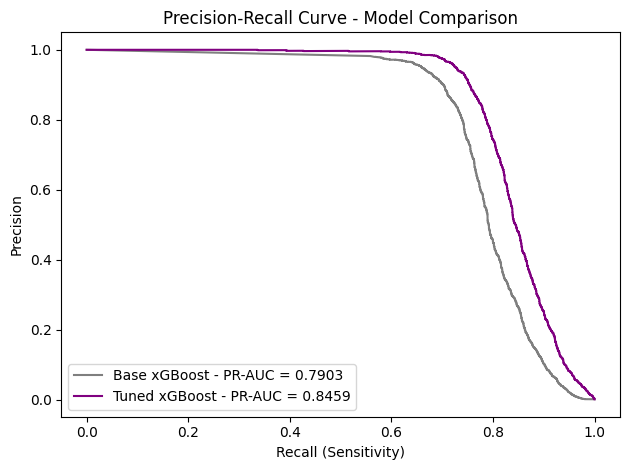

In [29]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np

precision, recall, _ = precision_recall_curve(y_test, y_pred_xgb)
pr_auc = auc(recall, precision)
plt.plot(recall,
            precision,
            label=f'Base xGBoost - PR-AUC = {pr_auc:.4f}',
            color='black', alpha=0.5)

precision, recall, _ = precision_recall_curve(y_test, y_pred_xgb_tuned)
pr_auc = auc(recall, precision)
plt.plot(recall,
            precision,
            label=f'Tuned xGBoost - PR-AUC = {pr_auc:.4f}',
            color='purple')

plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Model Comparison")
plt.legend()
plt.tight_layout()
plt.show()